In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d
from ovo_svm import OvO_SVM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
# import easyocr

In [4]:
# model = joblib.load("hog_manual_svm_model.joblib")
# x = joblib.load("../visual/x_features_hog.joblib")
# y = joblib.load("../visual/y_labels_hog.joblib")
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
# train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
model = OvO_SVM().load("./models/from_scratch_SVM")
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")


In [5]:
# label_encoder = joblib.load("label_encoder.joblib")

In [6]:
img = cv2.imread("./images/ocr.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [7]:
# reader = easyocr.Reader(['en'])
# results = reader.readtext("./images/ocr.jpeg")

In [8]:
# for _, text, confidence in results:
#     print(text, confidence)

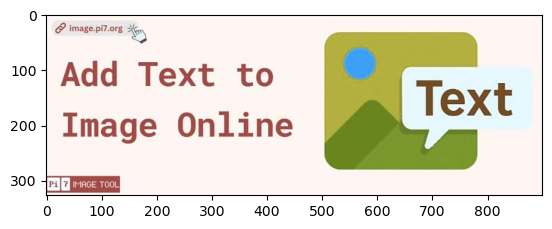

In [9]:
plt.imshow(img)

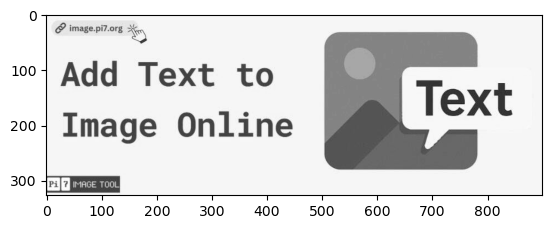

In [10]:
plt.imshow(gray, cmap='gray')

In [11]:
mser = cv2.MSER_create()
# mser.setMinArea()

In [12]:
def merge_boxes(boxes, threshold=0.3):
    merged = []

    for box in boxes:
        x, y, w, h = box
        if w == 0 or h == 0:
            continue

        added = False

        for i, (mx, my, mw, mh) in enumerate(merged):

            # compute IoU
            xi1 = max(x, mx)
            yi1 = max(y, my)
            xi2 = min(x + w, mx + mw)
            yi2 = min(y + h, my + mh)

            inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

            area1 = w * h
            area2 = mw * mh
            union = area1 + area2 - inter

            iou = inter / (union + 1e-6)

            if iou > threshold:
                # merge boxes
                nx = min(x, mx)
                ny = min(y, my)
                nw = max(x + w, mx + mw) - nx
                nh = max(y + h, my + mh) - ny

                merged[i] = (nx, ny, nw, nh)
                added = True
                break

        if not added:
            merged.append((x, y, w, h))

    return merged

In [13]:
# def remove_holes(boxes, threshold=0.5):
#     filtered = []
#     for box in boxes:
#         x, y, w, h = box
#         roi = gray[y:y+h, x:x+w]
#         roi = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
#         total_pixels = w * h
#         white_pixels = cv2.countNonZero(roi)
#         if white_pixels / total_pixels > threshold:
#             filtered.append(box)
#     return filtered

In [14]:
def filter_char_boxes(boxes, lower_bound=0.1, higher_bound=2.5):
    filtered = []
    for box in boxes:
        x, y, w, h = box
        if w == 0 or h == 0:
            continue
        aspect_ratio = w / (h + 1e-6)
        if lower_bound <= aspect_ratio <= higher_bound:
            filtered.append(box)
    return filtered

Number of regions: 793
Number of boxes: 793
Number of unique boxes: 52


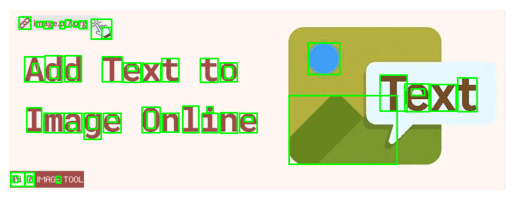

In [15]:
plt.axis('off')

regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
unique_boxes = merge_boxes(unique_boxes, threshold=0.3)
unique_boxes = filter_char_boxes(unique_boxes, lower_bound=0.1, higher_bound=2.5)

print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()
box_0 = unique_boxes[0]
char_0 = gray[box_0[1]:box_0[1]+box_0[3], box_0[0]:box_0[0]+box_0[2]]


In [16]:
def merge_char_words(boxes, x_thresh=20, y_thresh=10):
    used = [False] * len(boxes)
    words = []

    for i in range(len(boxes)):
        if used[i]:
            continue

        word = [boxes[i]]
        used[i] = True

        changed = True

        while changed:
            changed = False

            for j in range(len(boxes)):
                if used[j]:
                    continue

                x1, y1, w1, h1 = boxes[j]

                for wx, wy, ww, wh in word:
                    # check same line
                    if abs(wy - y1) < y_thresh:
                        # check horizontal gap
                        if abs((wx + ww) - x1) < x_thresh or abs((x1 + w1) - wx) < x_thresh:
                            word.append(boxes[j])
                            used[j] = True
                            changed = True
                            break

        words.append(sorted(word, key=lambda b: b[0]))

    return words

In [17]:
def get_word_boxes(words):
    word_boxes = []

    for word in words:
        x_min = min(x for x, y, w, h in word)
        y_min = min(y for x, y, w, h in word)
        x_max = max(x + w for x, y, w, h in word)
        y_max = max(y + h for x, y, w, h in word)

        word_boxes.append((x_min, y_min, x_max - x_min, y_max - y_min))

    return word_boxes

In [18]:
words = merge_char_words(unique_boxes, x_thresh=10, y_thresh=20)
print(f"Number of words: {len(words)}")

Number of words: 26


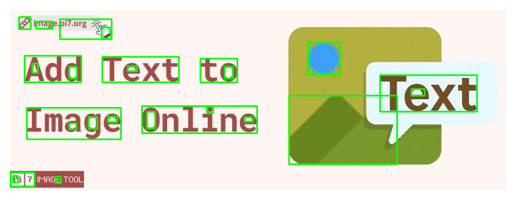

26


In [19]:
word_boxes = get_word_boxes(words)

img_copy = img.copy()

for (x, y, w, h) in word_boxes:
    cv2.rectangle(
        img_copy,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(img_copy)
plt.axis("off")
plt.show()
print(len(words))

In [20]:
IMG_SIZE = 128
def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation


def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

In [21]:
def predict(features, model=model, le=le):
    features = np.asarray(features)

    if features.ndim == 1:
        features = features.reshape(1, -1)

    model.classes = np.asarray(model.classes)
    predicted_label = model.predict(features)
    props = model.predict_proba(features)
    confidence = model.confidence(features)
    return predicted_label, confidence, props


In [22]:
def sort_boxes_reading_order(boxes, y_thresh=10):
    # first sort by y
    boxes = sorted(boxes, key=lambda b: b[1])

    lines = []

    for box in boxes:
        x, y, w, h = box
        placed = False

        for line in lines:
            if abs(line[0][1] - y) < y_thresh:
                line.append(box)
                placed = True
                break

        if not placed:
            lines.append([box])

    # sort each line by x
    for line in lines:
        line.sort(key=lambda b: b[0])

    # flatten
    return [b for line in lines for b in line]

In [23]:
char_non_char_model = joblib.load("./models/oc_svm_model.joblib")

Number of words: 10
char_non_char_pred: [1]
[0.040115419715166384, 0.03748206775719578, 0.03670248519725425]
1.0702563149671767
Predicted label for test image: a


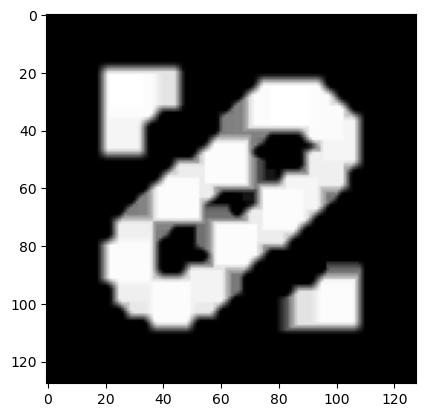

char_non_char_pred: [1]
[0.041855557837251846, 0.04155258260870963, 0.03839663753877771]
1.007291369381183
Predicted label for test image: M


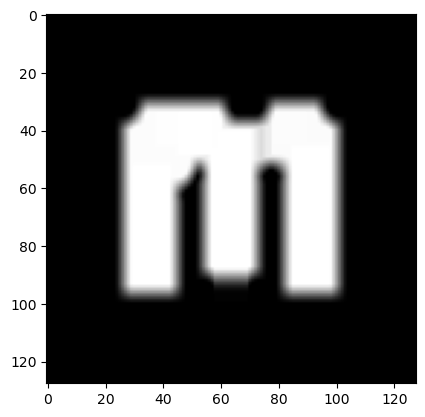

char_non_char_pred: [1]
[0.039807464394440197, 0.03933492419818776, 0.03818987238019443]
1.0120132479186068
Predicted label for test image: M


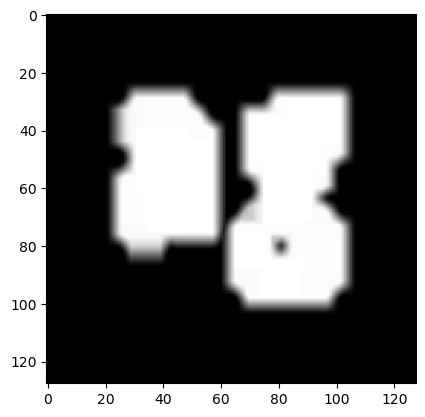

char_non_char_pred: [1]
[0.04048955359593277, 0.03950980654251137, 0.037740168025381285]
1.0247975664565006
Predicted label for test image: P


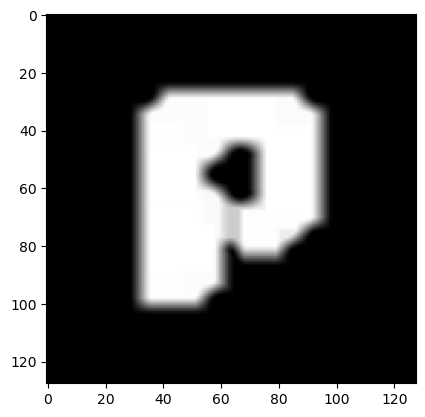

char_non_char_pred: [1]
[0.038360197985494934, 0.03719782079773721, 0.036877975039616435]
1.031248529156537
Predicted label for test image: n


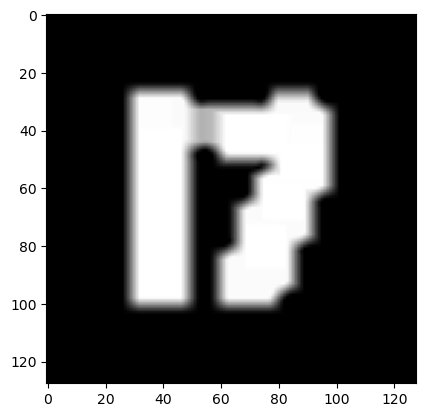

char_non_char_pred: [1]
[0.03944319755875294, 0.039187423245991754, 0.038620583047208897]
1.0065269489947224
Predicted label for test image: D


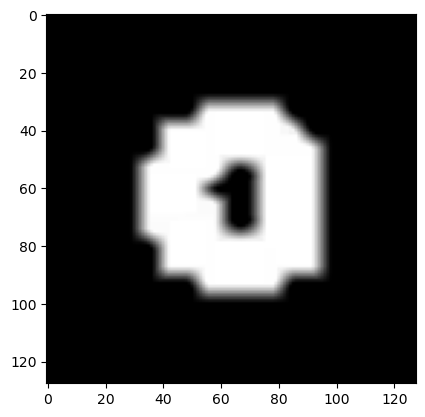

char_non_char_pred: [1]
[0.039951393189456376, 0.03937334595313387, 0.03866265160351482]
1.0146811814523093
Predicted label for test image: n


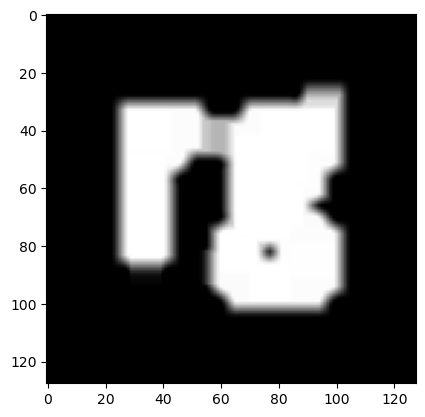

char_non_char_pred: [1]
[0.03904722471627833, 0.03839805915753263, 0.03698831139626763]
1.0169062075789408
Predicted label for test image: H


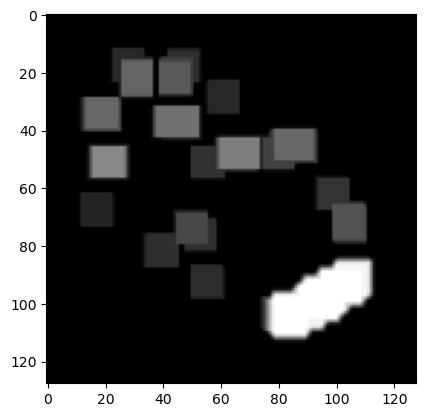

char_non_char_pred: [1]
[0.03946036648302864, 0.037788520524884725, 0.03738211044073562]
1.0442421649464408
Predicted label for test image: D


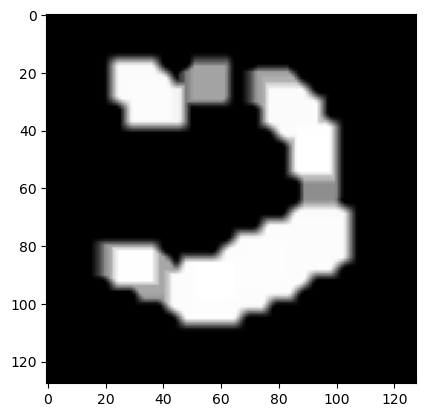

char_non_char_pred: [1]
[0.036844775771308035, 0.03458122302940056, 0.03435227062204133]
1.0654561216641478
Predicted label for test image: U


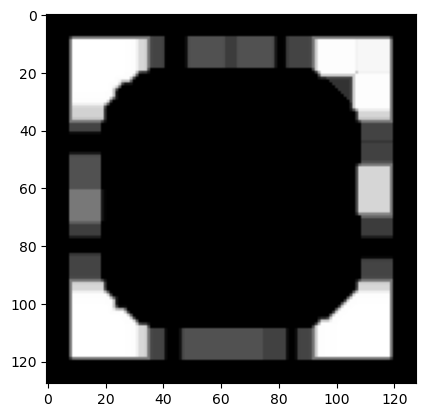

char_non_char_pred: [1]
[0.04113435400798933, 0.03797015699857287, 0.03564692972394798]
1.0833337878886145
Predicted label for test image: A


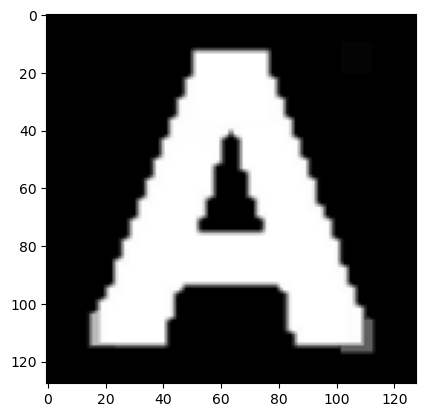

char_non_char_pred: [1]
[0.039879153514352186, 0.03917239329987274, 0.037747432932688924]
1.018042303646577
Predicted label for test image: U


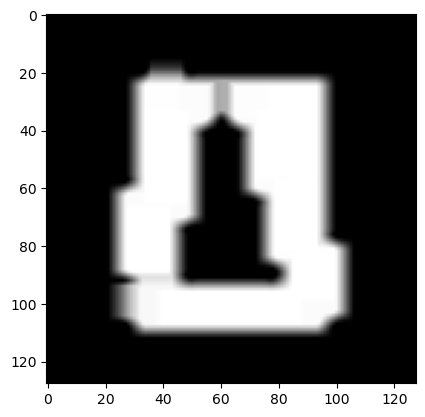

char_non_char_pred: [1]
[0.04200588747421547, 0.040596477906249095, 0.03844837034949041]
1.0347175331618959
Predicted label for test image: d


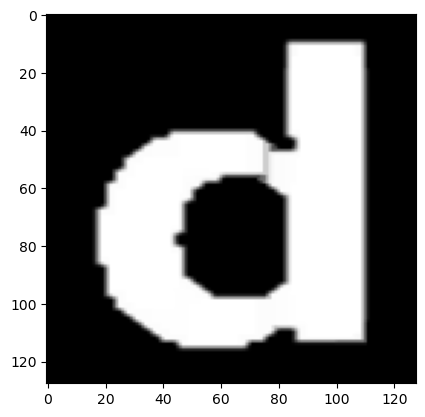

char_non_char_pred: [1]
[0.04075719756883172, 0.039823543224843924, 0.0369768154019654]
1.0234447833713936
Predicted label for test image: U


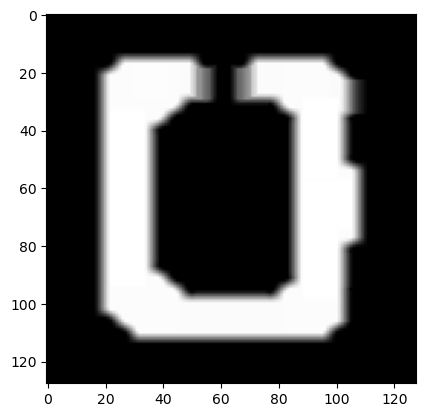

char_non_char_pred: [1]
[0.0419467460023781, 0.04057144495225535, 0.0383993863665498]
1.0338982516334139
Predicted label for test image: d


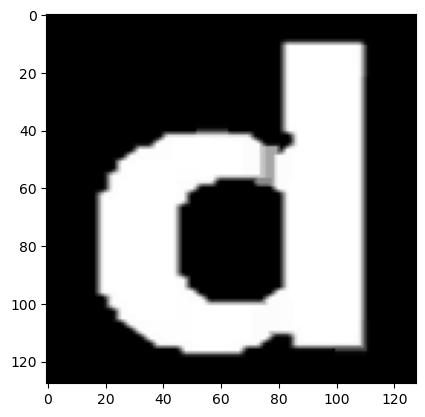

char_non_char_pred: [1]
[0.04123847278001483, 0.0403061122490972, 0.037029375103763695]
1.0231319886461765
Predicted label for test image: U


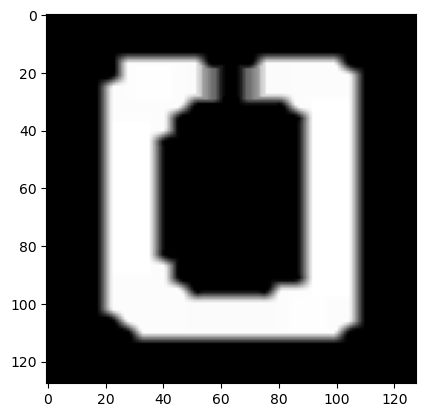

char_non_char_pred: [-1]
[0.04239186482424916, 0.04034499138628005, 0.03911271391371849]
1.0507342638488004
Predicted label for test image: T


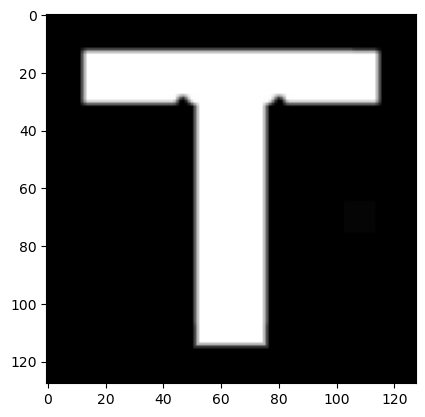

char_non_char_pred: [1]
[0.042292183827838656, 0.039795769091299144, 0.03862590509416129]
1.0627306568899888
Predicted label for test image: e


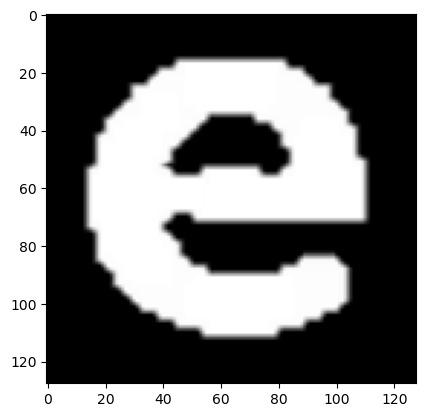

char_non_char_pred: [1]
[0.04060485068267027, 0.040177631275399965, 0.03974169023014861]
1.0106332651704106
Predicted label for test image: a


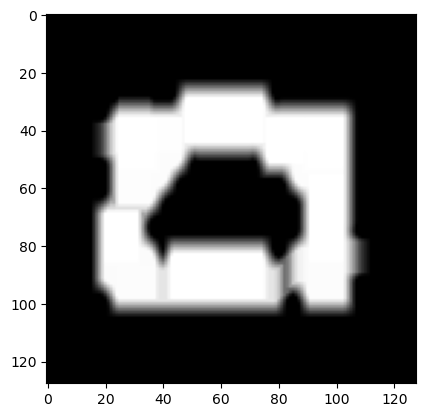

char_non_char_pred: [1]
[0.04224136480606461, 0.038774935270220905, 0.03847830055073219]
1.0893987188292205
Predicted label for test image: X


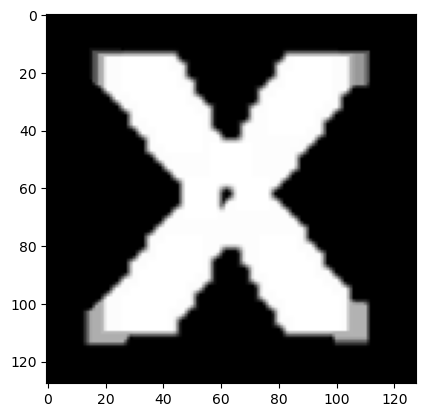

char_non_char_pred: [-1]
[0.04151628361890183, 0.03610856613339932, 0.035962729122066654]
1.1497627312456622
Predicted label for test image: t


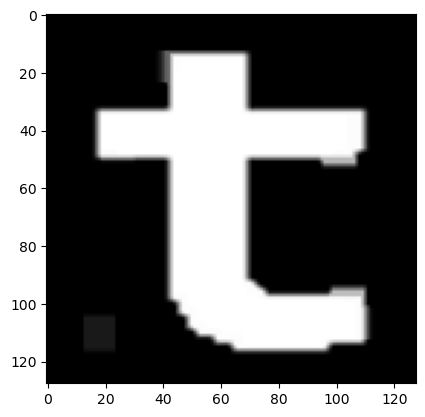

char_non_char_pred: [-1]
[0.04188307733392137, 0.03800827328833679, 0.03553748888977171]
1.101946331952249
Predicted label for test image: t


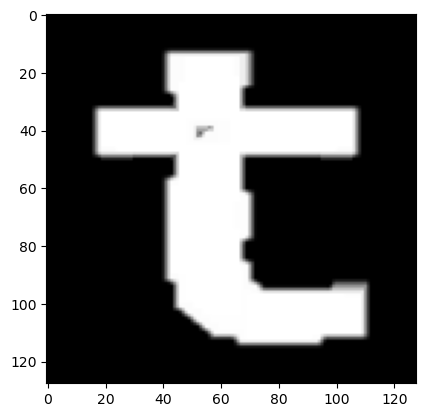

char_non_char_pred: [1]
[0.0413571915421292, 0.0386840771664577, 0.03755513729006984]
1.069101154052844
Predicted label for test image: O


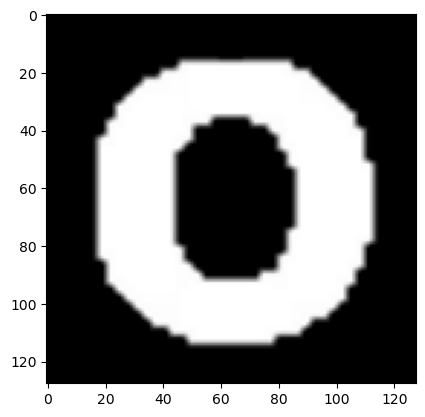

char_non_char_pred: [1]
[0.041330546264225256, 0.03898790491076699, 0.03676917501407763]
1.0600863616247127
Predicted label for test image: U


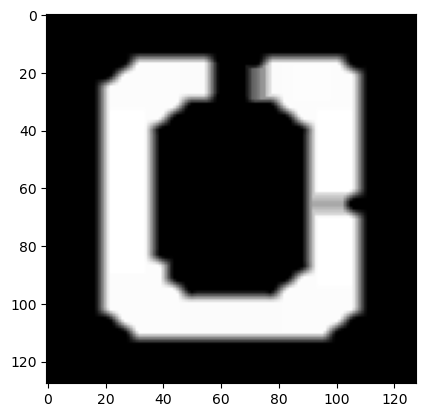

char_non_char_pred: [1]
[0.03979541174965983, 0.03859819209534451, 0.03832976352604811]
1.0310175059846836
Predicted label for test image: J


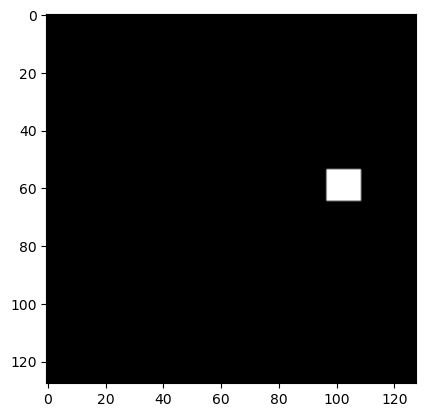

char_non_char_pred: [1]
[0.04208351436011571, 0.03915062455284124, 0.03772477541530378]
1.0749129762493566
Predicted label for test image: T


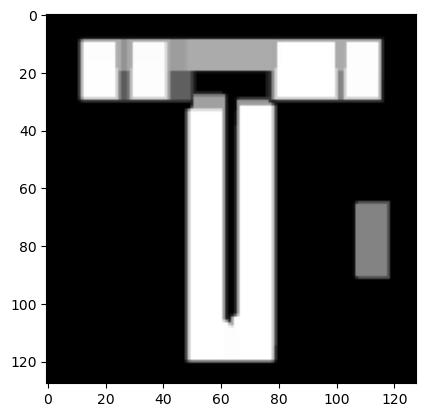

char_non_char_pred: [-1]
[0.04232247702223234, 0.03920152805113821, 0.03816675234806139]
1.0796129417971376
Predicted label for test image: e


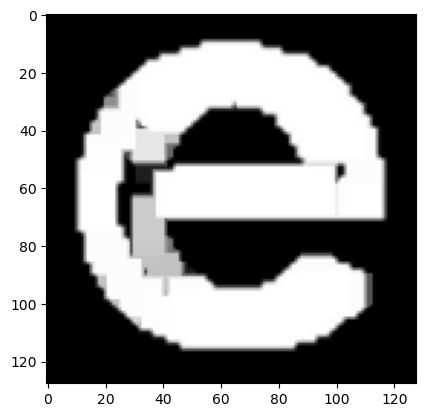

char_non_char_pred: [1]
[0.03960515019157483, 0.03739536701974029, 0.03732299001615047]
1.059092431708667
Predicted label for test image: n


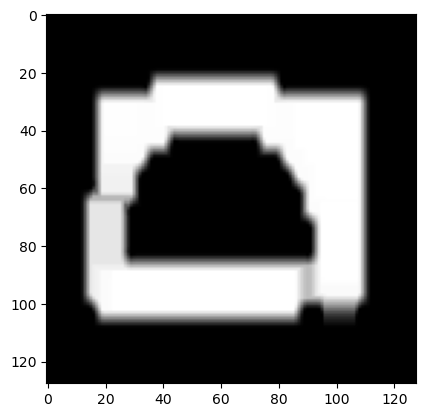

char_non_char_pred: [1]
[0.039808407147442826, 0.038326968732946415, 0.035595856381116654]
1.0386526371239724
Predicted label for test image: X


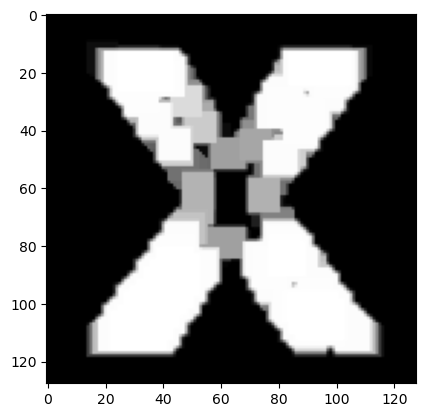

char_non_char_pred: [-1]
[0.04145568185409992, 0.03826086579799196, 0.036372629174881925]
1.083500882415359
Predicted label for test image: t


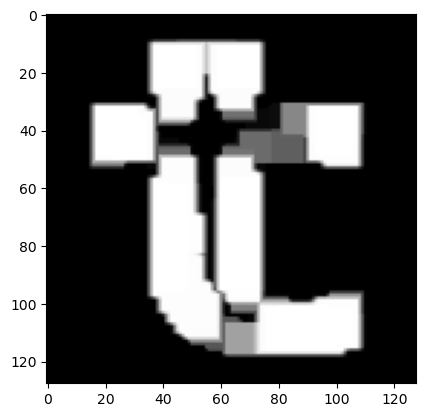

char_non_char_pred: [-1]
[0.039426478801006345, 0.03770262707004613, 0.03708364122332397]
1.0457223240109381
Predicted label for test image: T


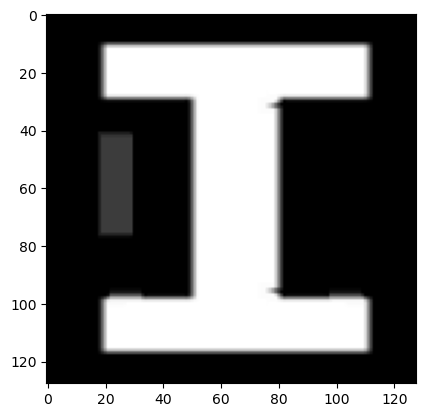

char_non_char_pred: [1]
[0.04179983050773786, 0.041730396410067656, 0.038233211941923646]
1.001663873426648
Predicted label for test image: M


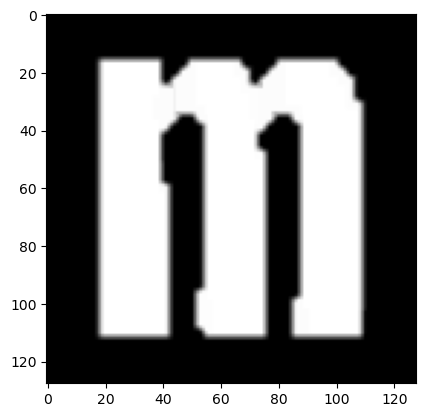

char_non_char_pred: [1]
[0.04231903547968414, 0.03980649310493636, 0.03664427046091008]
1.0631189079662031
Predicted label for test image: a


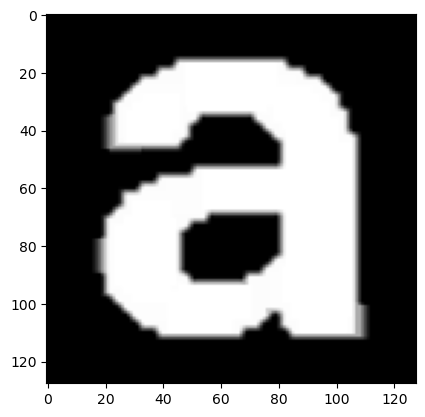

char_non_char_pred: [1]
[0.039740166269297425, 0.03873582231047651, 0.037433242999981305]
1.0259280402200028
Predicted label for test image: a


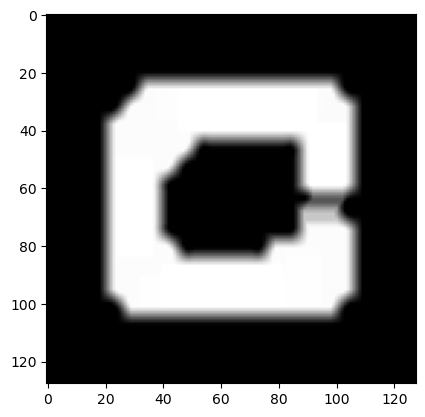

char_non_char_pred: [1]
[0.04094831327095726, 0.038262593882261955, 0.03778603761954736]
1.0701917752089558
Predicted label for test image: g


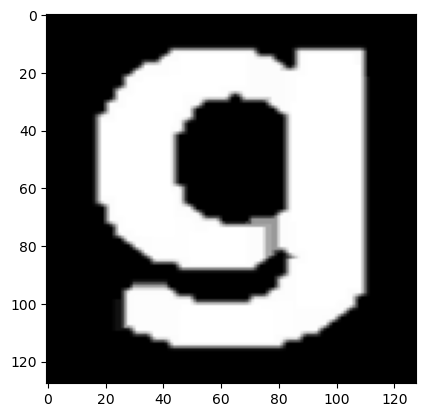

char_non_char_pred: [1]
[0.04060320734475322, 0.03939578891999609, 0.03837063571735622]
1.0306484133928406
Predicted label for test image: n


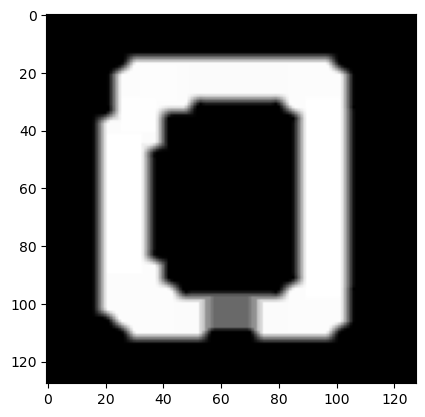

char_non_char_pred: [1]
[0.04248038297275261, 0.04068645536307237, 0.039087983041082706]
1.0440915187541366
Predicted label for test image: e


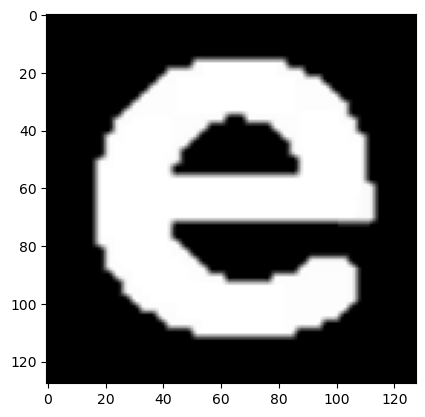

char_non_char_pred: [1]
[0.040234585155282665, 0.03826421752864597, 0.03774914217138075]
1.0514937389000991
Predicted label for test image: E


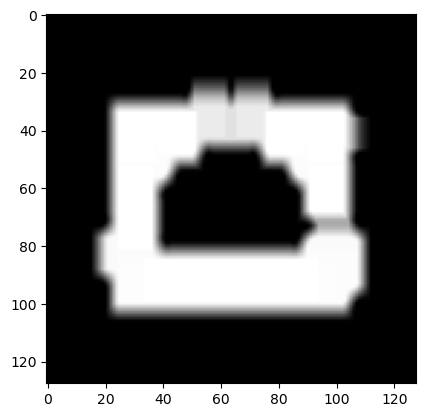

char_non_char_pred: [1]
[0.04155621450435563, 0.03970005312868321, 0.03828083301497028]
1.0467546320317478
Predicted label for test image: O


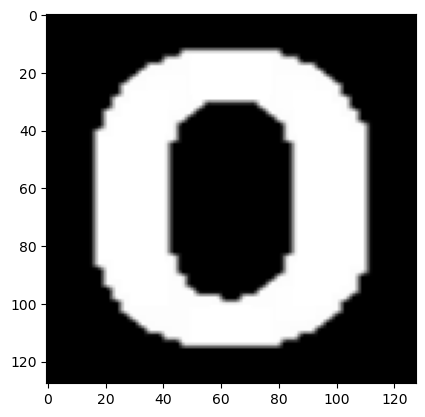

char_non_char_pred: [1]
[0.04086978248997328, 0.040702530236685124, 0.03979541591288636]
1.0041091365159753
Predicted label for test image: N


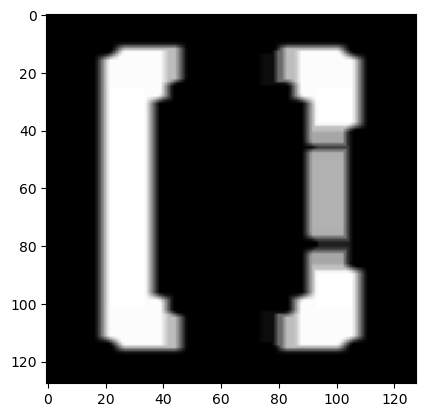

char_non_char_pred: [1]
[0.04238609975556692, 0.037699880868125195, 0.03768675863803184]
1.124303281059009
Predicted label for test image: n


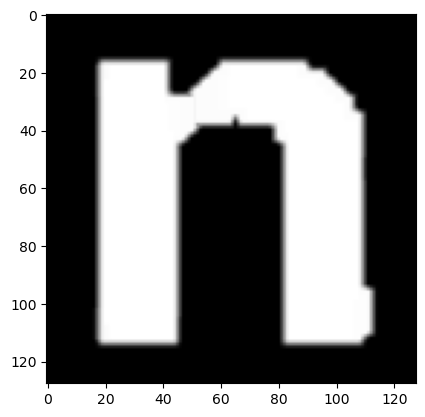

char_non_char_pred: [-1]
[0.040498274952450584, 0.03761434035735576, 0.03680742556034669]
1.076671146368538
Predicted label for test image: L


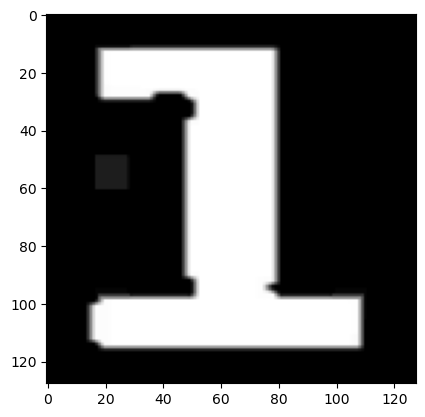

char_non_char_pred: [1]
[0.039641577740917075, 0.039565951567774815, 0.03818074984569428]
1.001911395281691
Predicted label for test image: L


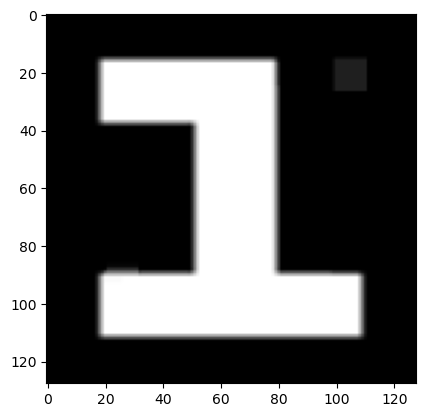

char_non_char_pred: [1]
[0.03828780283009731, 0.03661298019457384, 0.035800163708496036]
1.0457439581979642
Predicted label for test image: O


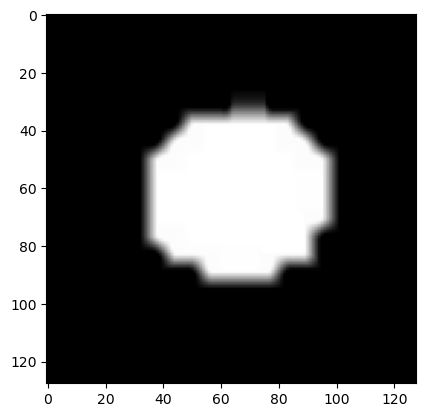

char_non_char_pred: [1]
[0.042456777037242314, 0.04006290035762585, 0.03786023535877177]
1.059752954934547
Predicted label for test image: n


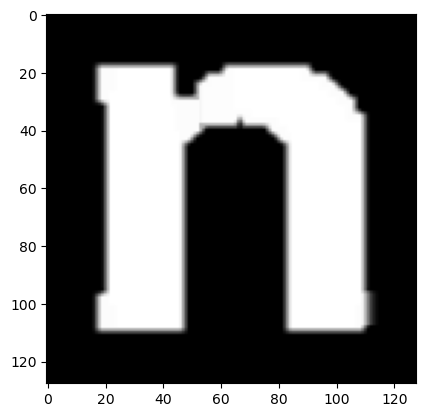

char_non_char_pred: [1]
[0.04247696364045024, 0.04055602282315972, 0.0394054803999871]
1.0473651182628678
Predicted label for test image: e


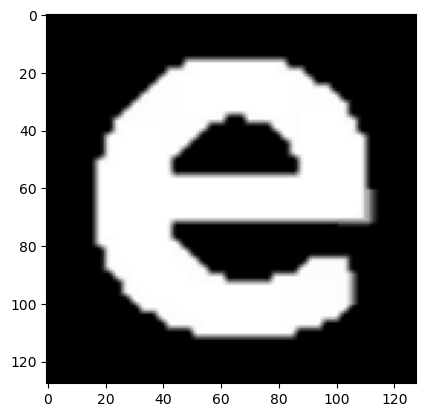

char_non_char_pred: [1]
[0.04105933447439583, 0.039233061922160466, 0.03881589562578081]
1.046549325052904
Predicted label for test image: H


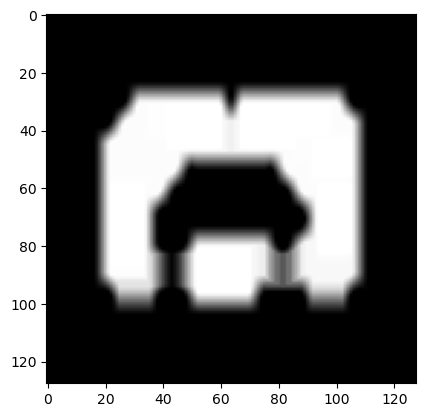

char_non_char_pred: [1]
[0.041025062078077365, 0.038428669023303635, 0.037874407078505]
1.0675639599487363
Predicted label for test image: E


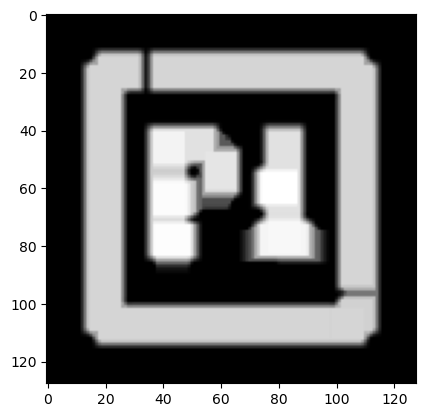

char_non_char_pred: [1]
[0.039160965937218864, 0.03724700490307812, 0.03420544287631463]
1.0513856359490148
Predicted label for test image: P


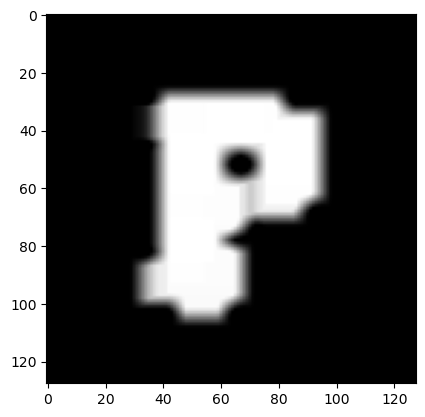

char_non_char_pred: [1]
[0.04009325038801113, 0.04004307599793031, 0.037672674768049454]
1.0012530103852013
Predicted label for test image: n


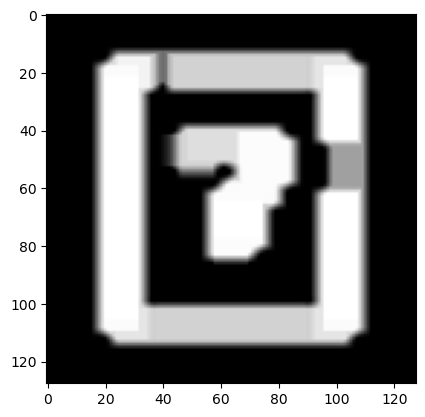

char_non_char_pred: [1]
[0.03593593145642646, 0.033911975583728646, 0.032284313088192955]
1.0596826294504922
Predicted label for test image: n


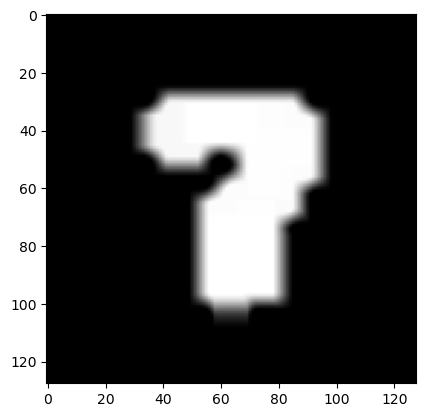

char_non_char_pred: [1]
[0.040878210169726065, 0.04071340637235759, 0.03851734753630055]
1.0040478999929705
Predicted label for test image: H


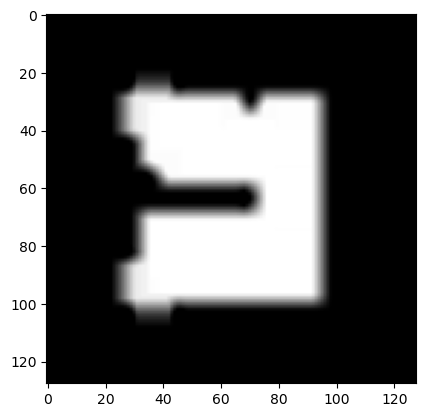

In [25]:
unique_boxes = sort_boxes_reading_order(unique_boxes, y_thresh=10)
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")
text = ""
for word in words:
    for box in word:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        # plt.imshow(char_img, cmap='gray')
        # plt.show()
        
        ## border
        padded_char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)
        ## blur
        blurred_char_img = cv2.GaussianBlur(padded_char_img, (5, 5), 0)

        ## binarize
        binarized_char_img = cv2.adaptiveThreshold(
            blurred_char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )

        
        ## resize
        resized_char_img = cv2.resize(
            binarized_char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )

        ## erode and dilate
        eroded = cv2.erode(resized_char_img, np.ones((5, 5), np.uint8), iterations=2)
        dilated = cv2.dilate(eroded, np.ones((3, 3), np.uint8), iterations=5)

        ## normalized
        normalized_char_img = dilated.astype(np.float32) / 255.0

        magnitudes, orientations = calc_gradients(normalized_char_img)
        features = HoG(orientations, magnitudes)
        # predicted_label, scores = predict(features)
        char_non_char_pred = char_non_char_model.predict(features.reshape(1, -1))
        print(f"char_non_char_pred: {char_non_char_pred}")
        predicted_label, confidence, props = predict(features)
        top3 = sorted(props[0], reverse=True)[:3]
        print(top3)
        print(top3[0]/top3[1])
        print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])
        plt.imshow(normalized_char_img, cmap='gray')
        plt.show()
        text += le.inverse_transform(predicted_label)[0]
        text += " "
    # text += " "

In [100]:
toLower = text.lower()
print(toLower)

a m m p n d n h d u a u d u d u t e a x t t o u j t e n x t t m a a g n e e o n n l l o n e h e p n n h 
